# Product Cluster Analysis

## Introduction

Welcome to the **Product Cluster Analysis** project.

This project aims to apply unsupervised machine learning techniques to identify **similar product groups based on historical sales patterns**. By clustering products, businesses can make data-driven decisions for inventory planning, promotions, and product bundling strategies.

The insights generated through clustering can help organizations:

- Optimize product stocking based on behavior-driven groupings  
- Tailor marketing strategies to specific product segments  
- Improve operational efficiency and forecasting

---

## Problem Statement

Retail and warehouse environments often handle a wide range of products with diverse sales patterns. Without meaningful segmentation, it becomes challenging to manage inventory and extract actionable insights.

Problems that arise due to lack of product clustering include:

- Overstocking or understocking specific products  
- Generalized marketing strategies that lack personalization  
- Difficulty in understanding product performance at scale

Unsupervised clustering methods provide a way to group products based on underlying sales trends, offering clarity and control over large product datasets.

---

## Objective

The goal of this project is to **cluster similar products** based on their sales behaviors (retail, warehouse, and transfers) using machine learning models. The ultimate aim is to enhance product-level decisions such as:

- Inventory control  
- Assortment planning  
- Category-based pricing and promotion

We will compare multiple clustering techniques to identify the best-performing model for segmenting products in a meaningful way.

---

## Dataset Description

The dataset used in this analysis includes **historical sales data for various product types**. It has been processed to extract statistical features such as mean, sum, and standard deviation for different sales channels.

| Attribute                  | Description                                                    |
|----------------------------|----------------------------------------------------------------|
| `ITEM TYPE`                | Category or name of the product                                |
| `RETAIL_SALES_*`           | Metrics related to sales from retail stores (mean, sum, std)   |
| `RETAIL_TRANSFERS_*`       | Metrics related to retail transfers (mean, sum, std)           |
| `WAREHOUSE_SALES_*`        | Metrics related to warehouse-level sales (mean, sum, std)      |
| `TOTAL_SALES`              | Total sales across all channels                                |
| `SALES_2017` to `SALES_2020`| Year-wise sales data                                          |

Additional columns such as `CLUSTER` and `CLUSTER_NAME` were added after clustering.

---

## Type of Machine Learning Task

This is an **Unsupervised Learning** task, specifically a **Clustering problem**, where the aim is to group products based on similarities in their sales statistics.

The following clustering algorithms are used and compared:

- K-Means  
- Agglomerative Clustering  
- DBSCAN  

Evaluation metrics used for comparison include:

- Silhouette Score  
- Calinski-Harabasz Index  
- Davies-Bouldin Index

Based on the performance metrics, the most appropriate model is selected for final segmentation.

---


# Importing Libraries

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Warehouse_and_Retail_Sales.csv')
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


## Dataset Basic Information

In [4]:
df.shape

(307645, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


In [6]:
df.describe()

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,307645.000000,307645.000000,307642.000000,307645.000000,307645.000000
mean,2018.438525,6.423862,7.024071,6.936465,25.294597
std,1.083061,3.461812,30.986238,30.237195,249.916798
min,2017.000000,1.000000,-6.490000,-38.490000,-7800.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,0.320000,0.000000,1.000000
75%,2019.000000,9.000000,3.267500,3.000000,5.000000
max,2020.000000,12.000000,2739.000000,1990.830000,18317.000000


**Skewed Sales Distributions**  
   - All three sales-related features (`RETAIL SALES`, `RETAIL TRANSFERS`, and `WAREHOUSE SALES`) exhibit **high standard deviations** relative to their means.  
   - For example, `WAREHOUSE SALES` has a **mean of 25.29** but a **standard deviation of 249.91**, indicating the presence of extreme values or outliers in the dataset.

**Presence of Negative Values**  
   - The dataset contains **negative values** for sales-related fields.  
   - Minimum values like `-6.49` in `RETAIL SALES`, `-38.49` in `RETAIL TRANSFERS`, and `-7800` in `WAREHOUSE SALES` suggest possible **returns, corrections, or data entry errors** that need further investigation.

**Sparsity in Retail Transfers**  
   - The **median (50th percentile)** for `RETAIL TRANSFERS` is **0**, and even the **75th percentile is just 3**, suggesting that **most products have low or no retail transfers** across records.  
   - This may indicate limited movement of products between retail locations.

**Temporal Coverage and Distribution**  
   - The dataset spans from **2017 to 2020** (`YEAR` column) and covers all **12 months**.  
   - However, the **mean year is 2018.43**, and **median year is 2019**, indicating that a **larger share of records** comes from more recent years in the dataset.

---


# Exploratory Data Analysis (EDA) & Data Wrangling

## Handling Missing Values

In [7]:
print(df.isnull().sum())

YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64


In [8]:
df['SUPPLIER'] = df['SUPPLIER'].fillna('Unknown')
df['ITEM TYPE'] = df['ITEM TYPE'].fillna('Unknown')
df['RETAIL SALES'] = df['RETAIL SALES'].fillna(df['RETAIL SALES'].median())
print(df.isnull().sum())

YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
dtype: int64


## Outlier Analysis

In [9]:
# Select relevant columns for analysis
cols = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']
original_data = df[cols]

# Make a copy for capping
capped_data = original_data.copy()

# Apply IQR method to cap outliers
for col in cols:
    Q1 = original_data[col].quantile(0.25)
    Q3 = original_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    capped_data[col] = original_data[col].clip(lower=lower_bound, upper=upper_bound)
    
    print(f"\n{col.upper()}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")



RETAIL SALES
Lower Bound: -4.89
Upper Bound: 8.15

RETAIL TRANSFERS
Lower Bound: -4.50
Upper Bound: 7.50

WAREHOUSE SALES
Lower Bound: -7.50
Upper Bound: 12.50


### Boxplot before capping

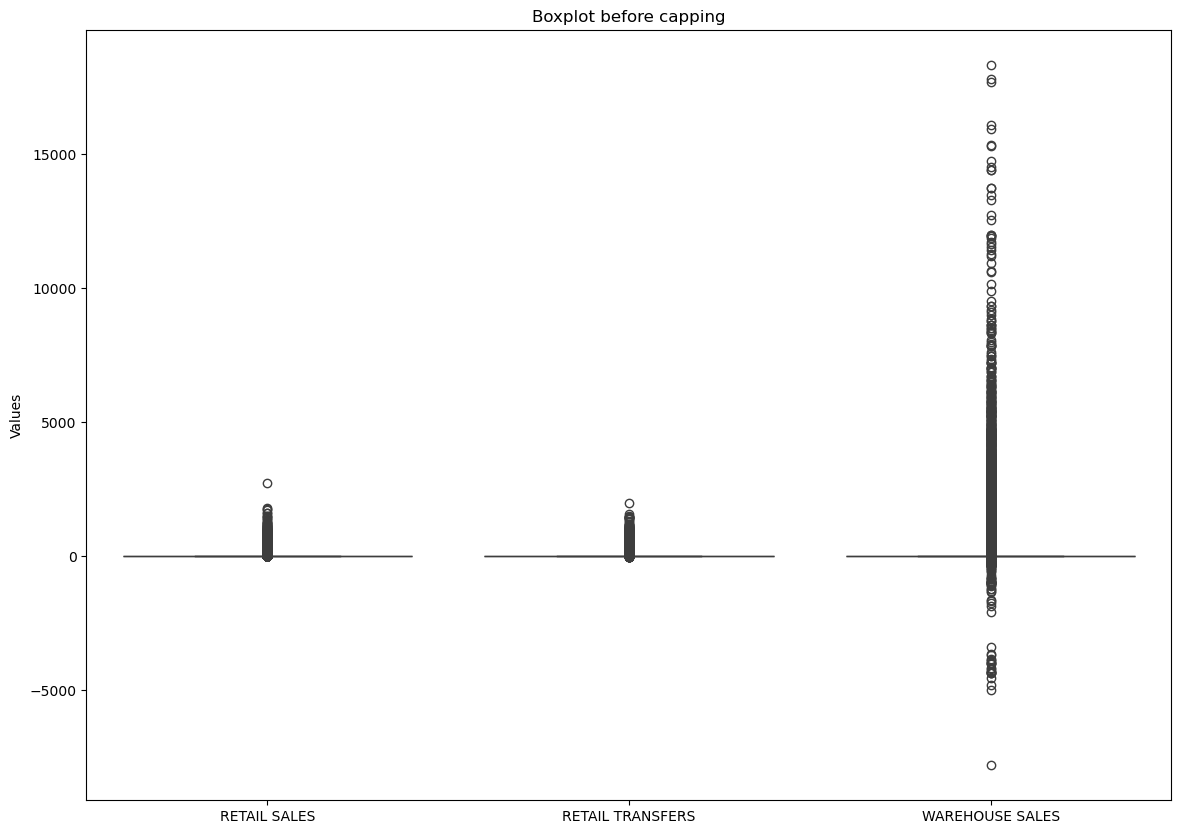

In [10]:
plt.figure(figsize=(14, 10))
sns.boxplot(data=original_data)
plt.title("Boxplot before capping")
plt.ylabel("Values");

A boxplot analysis was conducted to visualize the distribution and identify outliers in key sales-related features. The Interquartile Range (IQR) method was used to define the bounds for detecting outliers. Below are the key insights:

**Presence of High Outliers in Warehouse Sales**  
   - `WAREHOUSE SALES` displays a large number of high-value outliers, significantly above the upper bound of **12.50**.  
   - These outliers are extreme and can heavily influence the mean and overall distribution.

**Negative Values as Lower Outliers**  
   - All three features—`RETAIL SALES`, `RETAIL TRANSFERS`, and `WAREHOUSE SALES`—contain values below their respective lower bounds.  
   - These negative values could represent **returns, cancellations, or data inconsistencies** and should be handled cautiously.

**Retail Transfers and Retail Sales Have Limited Outlier Range**  
   - The outlier range for `RETAIL SALES` is from **-4.89 to 8.15**, and for `RETAIL TRANSFERS`, it is from **-4.50 to 7.50**.  
   - While they contain outliers, their distributions are **narrower** and relatively more **concentrated** than `WAREHOUSE SALES`.

**Need for Capping or Transformation**  
   - Due to the presence of **extreme outliers**, particularly in `WAREHOUSE SALES`, capping or log transformation may be necessary.  
   - This step is important to **reduce skewness**, **improve model performance**, and ensure **balanced clustering results** in later stages.

---
ping or transformation.



### Boxplot after capping

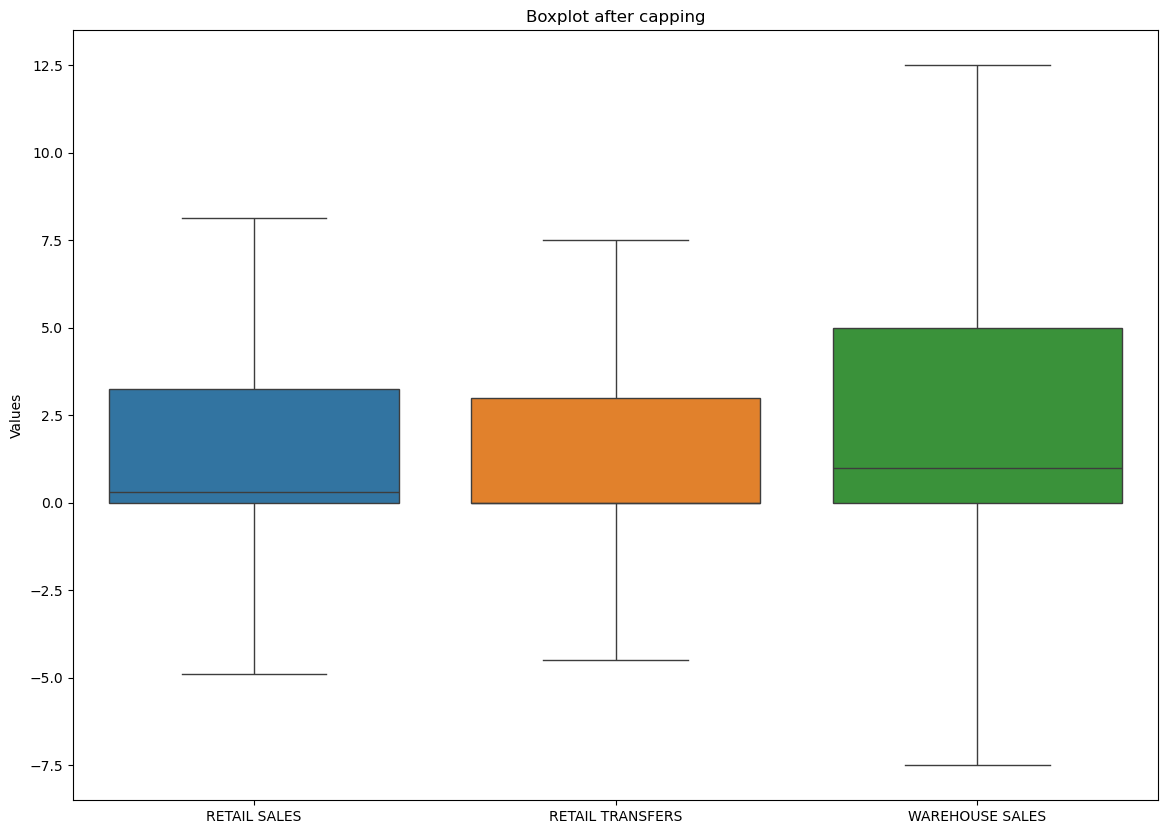

In [11]:
plt.figure(figsize=(14, 10))
sns.boxplot(data=capped_data)
plt.title("Boxplot after capping")
plt.ylabel("Values");

### Handling negative values

In [12]:
df['RETAIL SALES'] = df['RETAIL SALES'].clip(lower=0)
df['RETAIL TRANSFERS'] = df['RETAIL TRANSFERS'].clip(lower=0)
df['WAREHOUSE SALES'] = df['WAREHOUSE SALES'].clip(lower=0)
print(df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].min())

RETAIL SALES        0.0
RETAIL TRANSFERS    0.0
WAREHOUSE SALES     0.0
dtype: float64


   - Negative values in the sales-related columns (`RETAIL SALES`, `RETAIL TRANSFERS`, `WAREHOUSE SALES`) are not valid in this context, as sales quantities cannot be less than zero.  
   - To address this, we clipped the values at a lower bound of **0** to ensure data consistency and prevent misleading interpretations during analysis.
s.


# Data Visualization

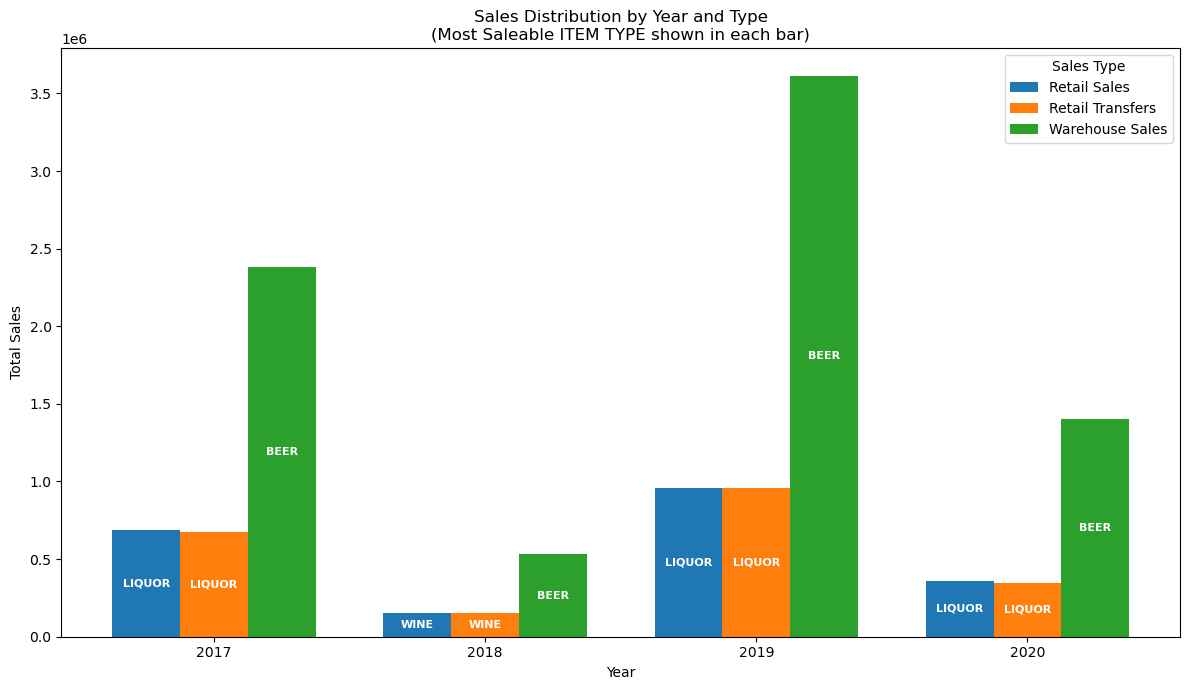

In [13]:
# Select numerical columns
sales_cols = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']
df[sales_cols] = df[sales_cols].apply(pd.to_numeric, errors='coerce')
df['YEAR'] = pd.to_numeric(df['YEAR'], errors='coerce')

# Filter for years 2017 to 2020
df = df[df['YEAR'].isin([2017, 2018, 2019, 2020])]

# Grouped totals by year
yearly_sales = df.groupby('YEAR')[sales_cols].sum()
years = yearly_sales.index.astype(int)
x = np.arange(len(years))
bar_width = 0.25

# Plotting the bars
plt.figure(figsize=(12, 7))
bars1 = plt.bar(x - bar_width, yearly_sales['RETAIL SALES'], width=bar_width, label='Retail Sales')
bars2 = plt.bar(x, yearly_sales['RETAIL TRANSFERS'], width=bar_width, label='Retail Transfers')
bars3 = plt.bar(x + bar_width, yearly_sales['WAREHOUSE SALES'], width=bar_width, label='Warehouse Sales')

# Function to find top ITEM TYPE for each year and sales column
def get_top_itemtype_labels(df, sales_type):
    labels = []
    for year in years:
        year_df = df[df['YEAR'] == year]
        top_item = year_df.groupby('ITEM TYPE')[sales_type].sum().idxmax()
        labels.append(top_item)
    return labels

# Get top ITEM TYPE labels
retail_labels = get_top_itemtype_labels(df, 'RETAIL SALES')
transfer_labels = get_top_itemtype_labels(df, 'RETAIL TRANSFERS')
warehouse_labels = get_top_itemtype_labels(df, 'WAREHOUSE SALES')

# Add labels inside each bar
for bar, label in zip(bars1, retail_labels):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5, label, ha='center', va='center',
             color='white', fontweight='bold', fontsize=8)

for bar, label in zip(bars2, transfer_labels):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5, label, ha='center', va='center',
             color='white', fontweight='bold', fontsize=8)

for bar, label in zip(bars3, warehouse_labels):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5, label, ha='center', va='center',
             color='white', fontweight='bold', fontsize=8)

# Labels and titles
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Sales Distribution by Year and Type\n(Most Saleable ITEM TYPE shown in each bar)')
plt.xticks(x, years)
plt.legend(title='Sales Type')
plt.tight_layout()
plt.show()

### Sales Distribution by Year and Type  
**(Most Saleable ITEM TYPE shown in each bar)**

- In 2019, Warehouse Sales peaked sharply, driven predominantly by BEER sales.  
- LIQUOR consistently held strong sales through Retail and Transfer channels between 2017–2020.  
- BEER emerged as the most dominant product in terms of Warehouse Sales across all years.  
- WINE and other categories showed minimal contribution compared to BEER and LIQUOR in all types of sales.


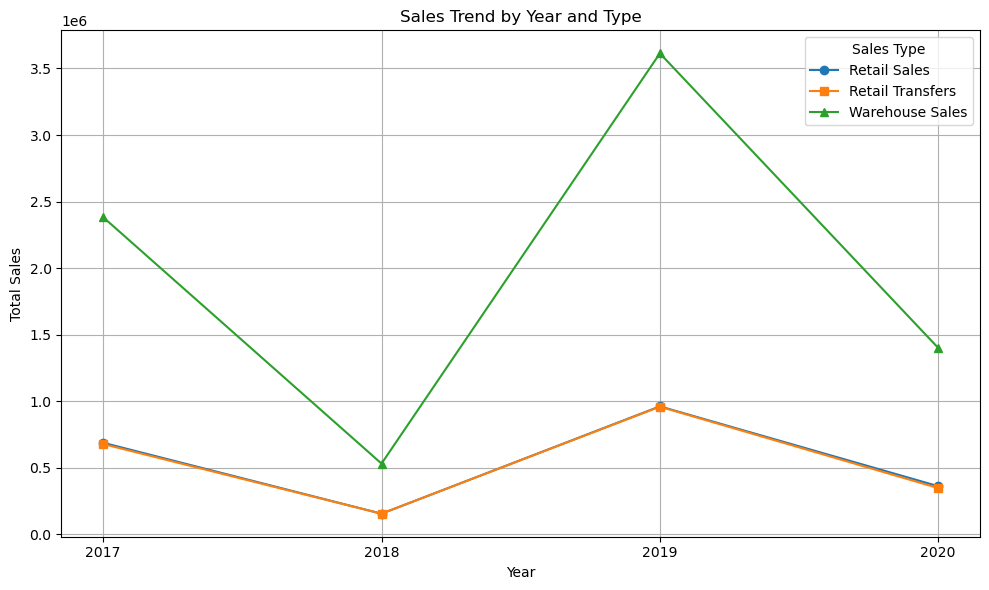

In [14]:
# Group by year and sum the sales columns
yearly_trend = df.groupby('YEAR')[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].sum().reset_index()

# Plotting the lines
plt.figure(figsize=(10, 6))
plt.plot(yearly_trend['YEAR'], yearly_trend['RETAIL SALES'], marker='o', label='Retail Sales')
plt.plot(yearly_trend['YEAR'], yearly_trend['RETAIL TRANSFERS'], marker='s', label='Retail Transfers')
plt.plot(yearly_trend['YEAR'], yearly_trend['WAREHOUSE SALES'], marker='^', label='Warehouse Sales')

# Labels and titles
plt.title('Sales Trend by Year and Type')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(yearly_trend['YEAR'])  # Ensure exact year ticks
plt.grid(True)
plt.legend(title='Sales Type')

plt.tight_layout()
plt.show()

### Sales Trend by Year and Type  

- All three sales types witnessed a significant dip in 2018 before rising again in 2019.  
- Warehouse Sales displayed a much larger magnitude compared to Retail Sales and Retail Transfers.  
- Retail Transfers and Retail Sales followed a similar trend over the years, both rising and falling together.  
- After the 2019 peak, all sales types declined in 2020, likely indicating a market disruption or external factor.


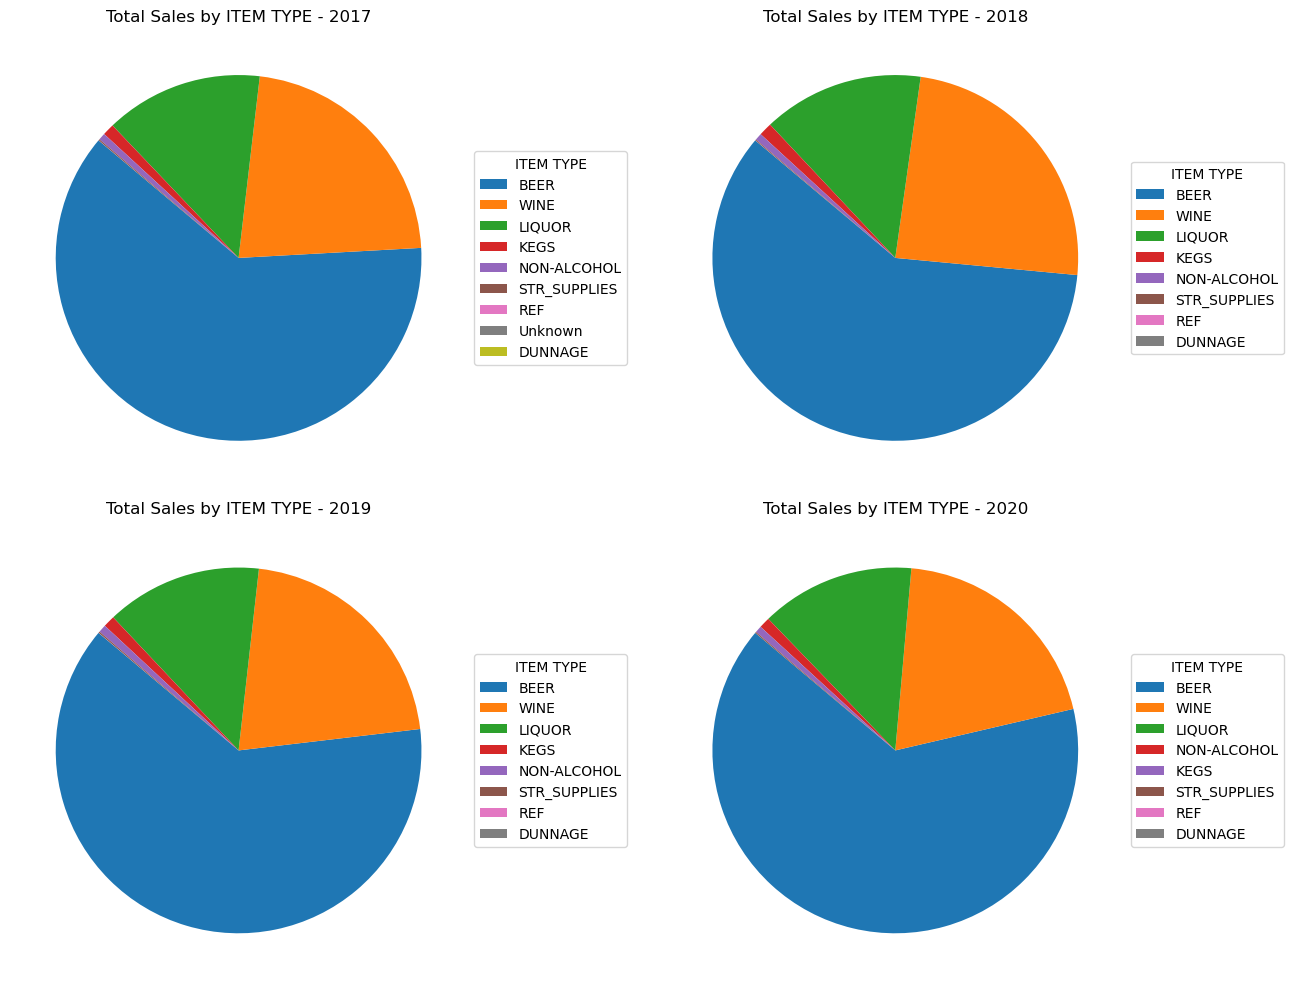

In [15]:
# Calculating Total Sales
df['TOTAL SALES'] = df['RETAIL SALES'] + df['RETAIL TRANSFERS'] + df['WAREHOUSE SALES']

# Set up 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
years = [2017, 2018, 2019, 2020]
axes = axes.flatten()

# Create pie charts
for i, year in enumerate(years):
    yearly_data = df[df['YEAR'] == year]
    item_sales = yearly_data.groupby('ITEM TYPE')['TOTAL SALES'].sum().sort_values(ascending=False)
    
    # Create pie chart without labels or % text
    wedges, texts = axes[i].pie(item_sales, labels=None, startangle=140)
    
    # Add legend (color index)
    axes[i].legend(wedges, item_sales.index, title="ITEM TYPE", loc="center left", bbox_to_anchor=(1, 0.5))
    axes[i].set_title(f'Total Sales by ITEM TYPE - {year}')

# Adjust layout
plt.tight_layout()
plt.show()

### Total Sales by ITEM TYPE - Pie Charts  

- **2017**: BEER dominated sales followed by LIQUOR and WINE.  
- **2018**: BEER remained the top product, while WINE slightly gained market share.  
- **2019**: BEER retained dominance, with stable performance by LIQUOR and WINE.  
- **2020**: BEER continued to lead, while LIQUOR remained consistent; other types showed minor changes.


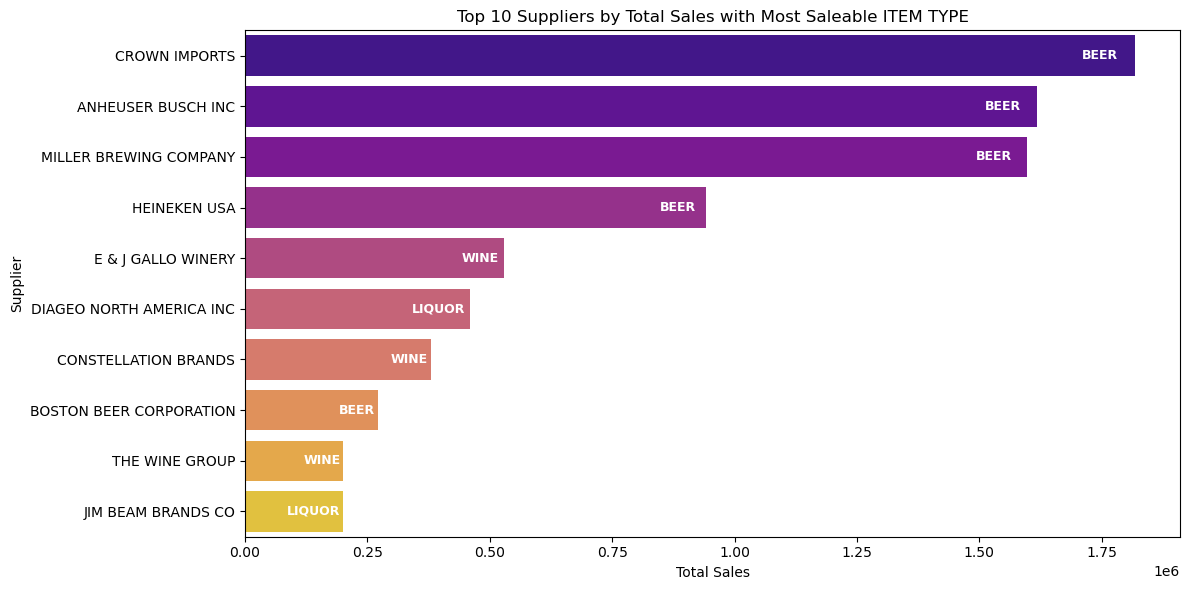

In [16]:
# Group by SUPPLIER and sum total sales, then get top 10
top_suppliers = df.groupby('SUPPLIER')['TOTAL SALES'].sum().sort_values(ascending=False).head(10)

# Get their most selling ITEM TYPE
labels = []
for supplier in top_suppliers.index:
    sub_df = df[df['SUPPLIER'] == supplier]
    top_item = sub_df.groupby('ITEM TYPE')['TOTAL SALES'].sum().idxmax()
    labels.append(top_item)

# Plot horizontal bar chart
plt.figure(figsize=(12, 6))
bars = sns.barplot(y=top_suppliers.index, x=top_suppliers.values, palette='plasma')

# Add most selling ITEM TYPE as bold white text inside each bar
for bar, label in zip(bars.patches, labels):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(width * 0.98, y, label, va='center', ha='right', color='white', fontweight='bold', fontsize=9)

# Add title and axis labels
plt.title('Top 10 Suppliers by Total Sales with Most Saleable ITEM TYPE')
plt.xlabel('Total Sales')
plt.ylabel('Supplier')
plt.tight_layout()
plt.show()

### Top 10 Suppliers by Total Sales with Most Saleable ITEM TYPE  

- CROWN IMPORTS led all suppliers with the highest total sales, primarily selling BEER.  
- The top four suppliers (CROWN IMPORTS, ANHEUSER BUSCH INC, MILLER BREWING COMPANY, and HEINEKEN USA) are all BEER-focused.  
- E & J GALLO WINERY and CONSTELLATION BRANDS were the key players in WINE distribution.  
- DIAGEO NORTH AMERICA INC and JIM BEAM BRANDS CO contributed significantly to LIQUOR sales among the top 10.


# Feature Engineering

In [17]:
df['YEAR'] = pd.to_numeric(df['YEAR'], errors='coerce')
df = df[df['YEAR'].isin([2017, 2018, 2019, 2020])]

# Convert sales columns to numeric
sales_cols = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']
df[sales_cols] = df[sales_cols].apply(pd.to_numeric, errors='coerce')
df.dropna(subset=sales_cols, inplace=True)

# Add total sales column
df['TOTAL SALES'] = df['RETAIL SALES'] + df['RETAIL TRANSFERS'] + df['WAREHOUSE SALES']

# Group by ITEM TYPE and calculate Mean, Total, Std Dev for each sales column
agg_funcs = ['mean', 'sum', 'std']
feature_df = df.groupby('ITEM TYPE')[sales_cols].agg(agg_funcs)

# Flatten multi-index columns
feature_df.columns = ['_'.join(col).upper().replace(' ', '_') for col in feature_df.columns]

# Add TOTAL SALES sum
total_sales = df.groupby('ITEM TYPE')['TOTAL SALES'].sum()
feature_df['TOTAL_SALES'] = total_sales

# Add year-wise total sales per ITEM TYPE
for year in [2017, 2018, 2019, 2020]:
    yearly_sales = df[df['YEAR'] == year].groupby('ITEM TYPE')['TOTAL SALES'].sum()
    feature_df[f'SALES_{year}'] = yearly_sales

# Fill missing year-item combos with 0
feature_df.fillna(0, inplace=True)

# Final Feature DataFrame
feature_df = feature_df[feature_df.index != 'Unknown']
feature_df.reset_index(inplace=True)  # This will convert the index back to a column named 'ITEM TYPE'

# Preview
print("Feature DataFrame ready for clustering:")
feature_df.head(12)

Feature DataFrame ready for clustering:


,ITEM TYPE,RETAIL_SALES_MEAN,RETAIL_SALES_SUM,RETAIL_SALES_STD,RETAIL_TRANSFERS_MEAN,RETAIL_TRANSFERS_SUM,RETAIL_TRANSFERS_STD,WAREHOUSE_SALES_MEAN,WAREHOUSE_SALES_SUM,WAREHOUSE_SALES_STD,TOTAL_SALES,SALES_2017,SALES_2018,SALES_2019,SALES_2020
0,BEER,13.538794,574220.86,57.506938,13.364496,566828.37,56.757002,153.914959,6527995.14,648.601789,7669044.37,2321991.46,499285.68,3483935.84,1363831.39
1,DUNNAGE,0.000000,0.00,0.000000,0.000000,0.00,0.000000,0.000000,0.00,0.000000,0.00,0.00,0.00,0.00,0.00
2,KEGS,0.000000,0.00,0.000000,0.000000,0.00,0.000000,11.691603,118623.00,41.597643,118623.00,39052.00,9798.00,57143.00,12630.00
3,LIQUOR,12.366455,802706.59,39.344195,12.248444,795046.49,39.338829,1.463629,95004.19,9.278024,1692757.27,522937.53,119121.22,763719.48,286979.04
4,NON-ALCOHOL,17.864439,34085.35,81.648297,13.978994,26671.92,27.080336,13.710304,26159.26,37.445908,86916.53,23080.32,5188.65,38336.73,20310.83
5,REF,5.226063,663.71,8.114034,3.062992,389.00,7.781488,2.346457,298.00,26.443224,1350.71,422.58,98.18,738.05,91.90
6,STR_SUPPLIES,6.767605,2740.88,22.621986,26.781679,10846.58,41.846970,0.000000,0.00,0.000000,13587.46,4132.84,695.66,6655.43,2103.53
7,WINE,3.978503,746526.31,13.772857,3.916751,734939.24,13.856473,6.168345,1157428.28,17.819017,2638893.83,834367.34,203315.46,1181120.74,420090.29


To prepare the dataset for clustering, we performed a series of feature engineering steps on the raw sales data:

**Data Cleaning**
   - Converted the `YEAR` column to numeric and filtered for years 2017 to 2020.
   - Converted sales columns (`RETAIL SALES`, `RETAIL TRANSFERS`, `WAREHOUSE SALES`) to numeric and dropped any rows with missing values in these columns.

**Derived Features**
   - Calculated **TOTAL SALES** for each record by summing across all three types of sales.

**Grouped Statistics**
   - Grouped the dataset by `ITEM TYPE` and computed the following statistics for each sales column:
     - **Mean**: Average sales per record.
     - **Sum**: Total sales.
     - **Standard Deviation**: Variation in sales.

**Year-wise Sales**
   - Added annual total sales columns (`SALES_2017`, `SALES_2018`, `SALES_2019`, `SALES_2020`) for each `ITEM TYPE`.

**Final Touch**
   - Missing values from year-item combinations were filled with 0.
   - Multi-index column names were flattened and standardized for readability.

---

### Output Feature DataFrame Structure

| Column Name                 | Description                              |
|----------------------------|------------------------------------------|
| `ITEM TYPE`                | Product type identifier                  |
| `RETAIL_SALES_MEAN`        | Average retail sale per record           |
| `RETAIL_SALES_SUM`         | Total retail sales                       |
| `RETAIL_SALES_STD`         | Standard deviation of retail sales       |
| `RETAIL_TRANSFERS_MEAN`    | Average retail transfer per record       |
| `RETAIL_TRANSFERS_SUM`     | Total retail transfers                   |
| `RETAIL_TRANSFERS_STD`     | Standard deviation of retail transfers   |
| `WAREHOUSE_SALES_MEAN`     | Average warehouse sale per record        |
| `WAREHOUSE_SALES_SUM`      | Total warehouse sales                    |
| `WAREHOUSE_SALES_STD`      | Standard deviation of warehouse sales    |
| `TOTAL_SALES`              | Combined total of all sales types        |
|`SALES_2017` to `SALES_2020`| Total sales for each year                ||


# Scaling & Model Building

In [18]:
# Drop ITEM TYPE temporarily
X = feature_df.drop(columns=['ITEM TYPE'])
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of X_scaled:", X_scaled.shape)
X_scaled

Shape of X_scaled: (8, 14)


array([[ 0.99443649,  0.88302208,  1.07551993,  0.48710546,  0.88235218,
         1.68425005,  2.63277939,  2.60573969,  2.63920091,  2.456667  ,
         2.44217638,  2.39447067,  2.46150401,  2.48831407],
       [-1.22321042, -0.78434019, -1.01182332, -1.06460189, -0.78485439,
        -1.17572899, -0.47827361, -0.4661971 , -0.46775849, -0.6110855 ,
        -0.61688376, -0.63525946, -0.60950206, -0.59519717],
       [-1.22321042, -0.78434019, -1.01182332, -1.06460189, -0.78485439,
        -1.17572899, -0.24195353, -0.41037562, -0.26849572, -0.56363422,
        -0.5654355 , -0.57580393, -0.55913187, -0.56664178],
       [ 0.80240804,  1.54647497,  0.41626247,  0.35752434,  1.55360784,
         0.80655021, -0.44868955, -0.42149013, -0.42331452,  0.06604715,
         0.07204959,  0.08758352,  0.06369839,  0.05363897],
       [ 1.70297481, -0.68536673,  1.95178471,  0.55845275, -0.70640454,
         0.18884611, -0.20114991, -0.4538871 , -0.28838354, -0.57631736,
        -0.58647706, -0.60

 - Before applying clustering algorithms, it is important to scale the features to ensure that all variables contribute equally to the distance calculations. Features like total sales and standard deviations vary in magnitude, and without scaling, larger numerical ranges could dominate the clustering results.

Here, we used **StandardScaler** to standardize the data, transforming each feature to have a mean of 0 and a standard deviation of 1.


## Determine Optimal Number of Clusters

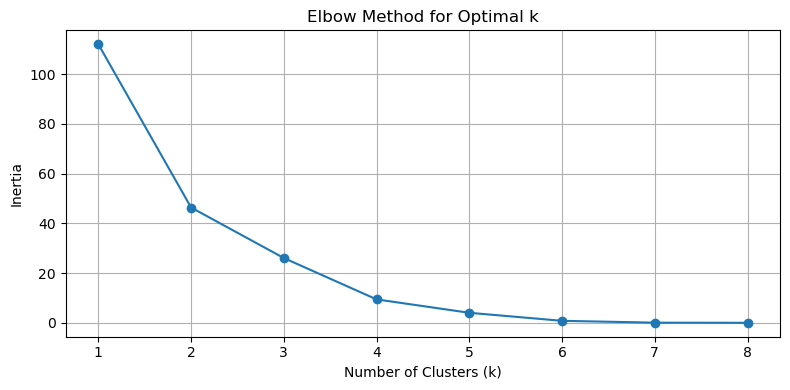

In [100]:
if X_scaled is None:
    raise ValueError("X_scaled is None. Please check your data preprocessing steps.")

# Ensure X_scaled is a numpy array
X_scaled = np.array(X_scaled)

max_k = min(10, X_scaled.shape[0])
inertia = []
k_range = range(1, max_k + 1)

for k in k_range:
    # Set n_init explicitly to avoid deprecation warnings
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()  # Helps avoid text being cut off
plt.show()

To determine the optimal number of clusters for K-Means, the Elbow Method was used. The plot shows the relationship between the number of clusters (k) and the inertia (sum of squared distances from points to their assigned cluster center). Here are some key insights:

**Sharp Drop at k=3**: There is a significant drop in inertia between k=1 and k=3, indicating that increasing the number of clusters in this range greatly improves clustering performance.

**Elbow Point Around k=3 or k=4**: After k=3, the rate of decrease in inertia slows down noticeably, suggesting the optimal k lies around 3 or 4, where adding more clusters yields diminishing returns.

**Diminishing Returns After k=4**: Beyond 4 clusters, the reduction in inertia becomes marginal, implying that further partitioning adds complexity without substantial improvement.

**Balancing Simplicity and Accuracy**: Choosing k=3 or k=4 balances model simplicity with clustering accuracy, helping avoid overfitting and underfitting in unsupervised learning.

Based on these insights, k=3 was selected as the optimal number of clusters for further analysis.
r analysis.


## Applying Models

In [101]:
# Dictionary to store models and their results
results = []

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=2)
dbscan_labels = dbscan.fit_predict(X_scaled)


- **K-Means, Agglomerative Clustering, and DBSCAN** were selected to apply different clustering strategies to the product sales data.
- Each algorithm has distinct strengths: K-Means for centroid-based clustering, Agglomerative for hierarchical structure, and DBSCAN for density-based grouping.
- Using multiple models allows us to **compare clustering quality and robustness** from different perspectives.
- The main objective is to identify which method most accurately **groups similar product types based on sales behavior** for better business insights.
.


## Evaluation of Models

In [102]:
# Function to evaluate clustering
def evaluate_model(name, labels):
    # Ignore noisy labels (-1) in DBSCAN if present
    mask = labels != -1
    if len(set(labels[mask])) > 1:  # Only evaluate if valid clusters exist
        sil = silhouette_score(X_scaled[mask], labels[mask])
        ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
        db = davies_bouldin_score(X_scaled[mask], labels[mask])
    else:
        sil = ch = db = np.nan
    results.append({
        'Model': name,
        'Silhouette Score': sil,
        'Calinski-Harabasz Index': ch,
        'Davies-Bouldin Index': db,
        'Clusters': len(set(labels)) - (1 if -1 in labels else 0)
    })

# Evaluate each model
evaluate_model('KMeans', kmeans_labels)
evaluate_model('Agglomerative', agglo_labels)
evaluate_model('DBSCAN', dbscan_labels)

# Create results DataFrame
results_df = pd.DataFrame(results)
print("\n Clustering Evaluation Results:")
results_df


 Clustering Evaluation Results:


,Model,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index,Clusters
0,KMeans,0.314998,8.252055,0.653132,3
1,Agglomerative,0.314998,8.252055,0.653132,3
2,DBSCAN,NaN,NaN,NaN,1


- All three clustering models were evaluated using **Silhouette Score**, **Calinski-Harabasz Index**, and **Davies-Bouldin Index**.
- **K-Means** and **Agglomerative Clustering** produced identical performance across all three metrics:
  - Silhouette Score: 0.3149  
  - Calinski-Harabasz Index: 8.25  
  - Davies-Bouldin Index: 0.6531  
  Both models identified **3 clusters**.
- **DBSCAN** failed to form meaningful clusters, grouping all data points into a single cluster, which led to invalid evaluation scores.
- Despite the equal performance of K-Means and Agglomerative, **Agglomerative Clustering** was selected due to its ability to capture hierarchical relationships and better interpretability fora this t.
set.


### Evaluation Plotting

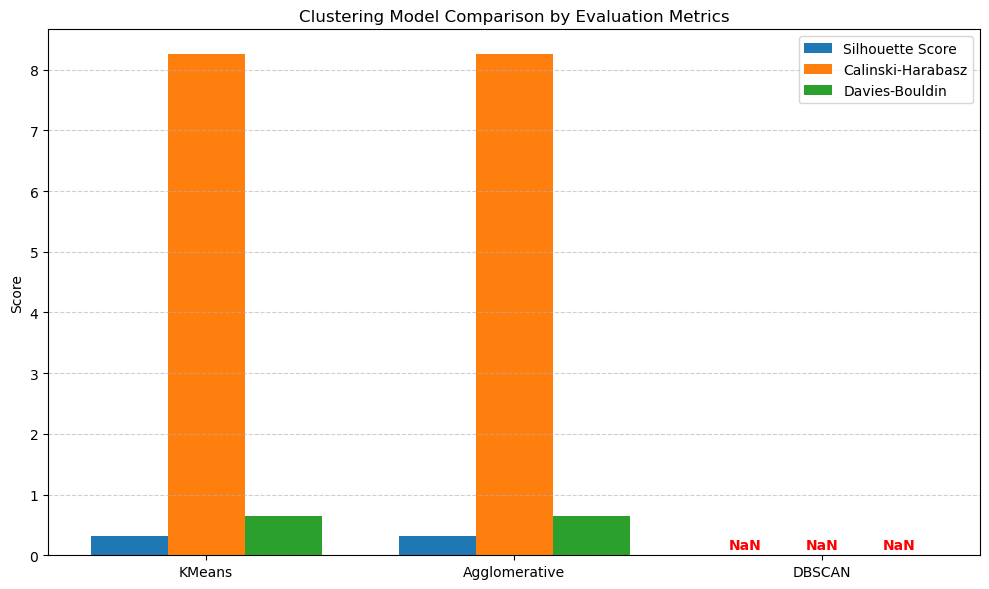

In [103]:
# Prepare the evaluation results
models = ['KMeans', 'Agglomerative', 'DBSCAN']
silhouette = [0.314998, 0.314998, np.nan]
calinski = [8.252055, 8.252055, np.nan]
davies = [0.653132, 0.653132, np.nan]

# Replace NaN with 0 for plotting
silhouette_clean = [0 if np.isnan(x) else x for x in silhouette]
calinski_clean = [0 if np.isnan(x) else x for x in calinski]
davies_clean = [0 if np.isnan(x) else x for x in davies]

# Bar width and positions
x = np.arange(len(models))  # positions for each model
width = 0.25

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(x - width, silhouette_clean, width=width, label='Silhouette Score')
plt.bar(x, calinski_clean, width=width, label='Calinski-Harabasz')
plt.bar(x + width, davies_clean, width=width, label='Davies-Bouldin')

# Chart details
plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Clustering Model Comparison by Evaluation Metrics')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Highlight DBSCAN failure
for i in range(len(models)):
    if np.isnan(silhouette[i]):
        plt.text(x[i] - width, 0.1, 'NaN', ha='center', color='red', fontweight='bold')
    if np.isnan(calinski[i]):
        plt.text(x[i], 0.1, 'NaN', ha='center', color='red', fontweight='bold')
    if np.isnan(davies[i]):
        plt.text(x[i] + width, 0.1, 'NaN', ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

- Both **KMeans** and **Agglomerative Clustering** models achieved identical evaluation scores across all three metrics, indicating equivalent clustering performance:
  - Silhouette Score: 0.3149
  - Calinski-Harabasz Index: 8.25
  - Davies-Bouldin Index: 0.6531
- The high Calinski-Harabasz values in both models suggest moderately well-separated clusters, while similar Davies-Bouldin values indicate comparable compactness and separation.
- **DBSCAN** failed to identify meaningful clusters, assigning all data points to a single cluster, which resulted in `NaN` values for all evaluation metrics.
- Since Agglomerative Clustering allows for hierarchical structure and interpretability advantages, it was selected as the final model despite identical metric scores with Keans.
ics.


## PCA Projection

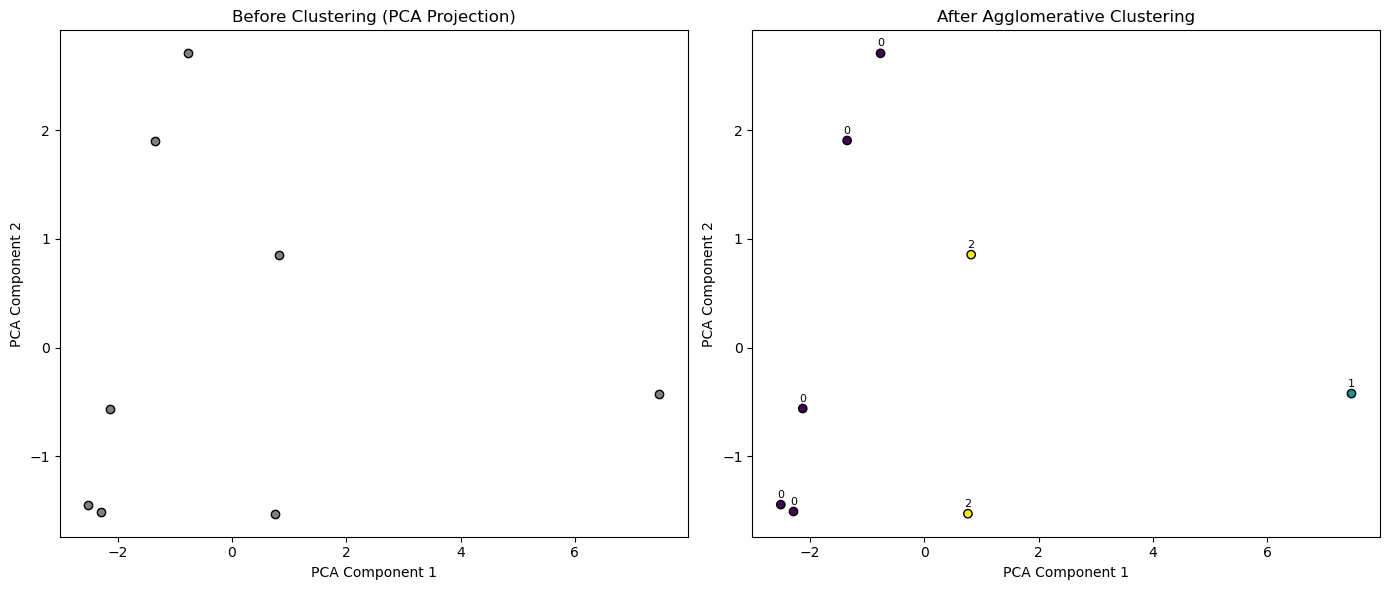

In [104]:
# PCA for 2D visualization ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Fit Agglomerative Clustering ===
agglo = AgglomerativeClustering(n_clusters=3)
labels = agglo.fit_predict(X_scaled)

# Add cluster labels to your dataframe ===
feature_df['CLUSTER'] = labels

# Visualization ===
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Before Clustering ---
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], color='gray', edgecolor='black')
axs[0].set_title("Before Clustering (PCA Projection)")
axs[0].set_xlabel("PCA Component 1")
axs[0].set_ylabel("PCA Component 2")

# --- After Clustering ---
scatter = axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='black')
axs[1].set_title("After Agglomerative Clustering")
axs[1].set_xlabel("PCA Component 1")
axs[1].set_ylabel("PCA Component 2")

# Annotate points with cluster labels
for i, txt in enumerate(labels):
    axs[1].annotate(txt, (X_pca[i, 0], X_pca[i, 1]), textcoords="offset points", xytext=(0, 5),
                    ha='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()


#### Before Applying Agglomerative Clustering (PCA Projection)

**Lack of Visual Grouping:**  
The data points are plotted without any clustering labels, and there is no visible separation or grouping. This suggests that the underlying structure is not immediately obvious in reduced dimensions.

**Presence of Outliers:**  
Most points are concentrated in a small region, but one point lies far to the right, indicating a potential outlier or a product with distinct behavior in terms of sales or distribution features.

#### After Applying Agglomerative Clustering (PCA Projection)

**Formation of Distinct Clusters:**  
Post-clustering, three well-separated clusters are visible, each marked by a unique label. This demonstrates the model’s ability to differentiate product types based on their features.

**Clustered Outlier Detection:**  
The point that previously appeared as an outlier has been assigned to its own cluster (label `1`), highlighting the model’s capability to isolate significantly different product profile from the rest.


### Cluster Analysis

In [105]:
# How many records in each cluster?
print(feature_df['CLUSTER'].value_counts())

# Summary stats by cluster
numeric_cols = feature_df.select_dtypes(include=['number']).columns
cluster_summary = feature_df.groupby('CLUSTER')[numeric_cols].mean()
cluster_summary

CLUSTER
0    5
2    2
1    1
Name: count, dtype: int64


,RETAIL_SALES_MEAN,RETAIL_SALES_SUM,RETAIL_SALES_STD,RETAIL_TRANSFERS_MEAN,RETAIL_TRANSFERS_SUM,RETAIL_TRANSFERS_STD,WAREHOUSE_SALES_MEAN,WAREHOUSE_SALES_SUM,WAREHOUSE_SALES_STD,TOTAL_SALES,SALES_2017,SALES_2018,SALES_2019,SALES_2020,CLUSTER
CLUSTER,,,,,,,,,,,,,,,
0,5.971621,7497.988,22.476864,8.764733,7581.500,15.341759,5.549673,29016.052,21.097355,44095.54,13337.548,3156.098,20574.642,7027.252,0.0
1,13.538794,574220.860,57.506938,13.364496,566828.370,56.757002,153.914959,6527995.140,648.601789,7669044.37,2321991.460,499285.680,3483935.840,1363831.390,1.0
2,8.172479,774616.450,26.558526,8.082598,764992.865,26.597651,3.815987,626216.235,13.548521,2165825.55,678652.435,161218.340,972420.110,353534.665,2.0



- **Cluster 0** contains the majority of product types (5 out of 8) with moderate sales and transfer values, indicating average-performing products.
- **Cluster 1** has only one product type but shows exceptionally high values across all metrics, identifying it as a high-performing, high-volume product.
- **Cluster 2** includes 2 product types with moderate-to-high retail and transfer volumes but significantly lower warehouse sales, suggesting a retail-focused distribution.
- The clustering effectively distinguishes between low, average, and high-performing product categories based on their sales and logistics characteristics.


### Cluster Labelling

In [106]:
# Most frequent ITEM TYPE per cluster
item_type_labels = feature_df.groupby('CLUSTER')['ITEM TYPE'].agg(lambda x: x.mode().iloc[0])
print(item_type_labels)

# add a new column with descriptive cluster names
feature_df['CLUSTER_NAME'] = feature_df['CLUSTER'].map(item_type_labels)

CLUSTER
0    DUNNAGE
1       BEER
2     LIQUOR
Name: ITEM TYPE, dtype: object



- **Cluster 0,** represents the **DUNNAGE** category, consisting of lower-volume or support products with moderate sales and transfers.
- **Cluster 1**, labeled as **BEER**, contains the highest-performing product type with exceptional sales across all channels.
- **Cluster 2**, labeled as **LIQUOR**, includes mid-range products with balanced retail and transfer activity but relatively low warehouse saes.


### Cluster Plotting

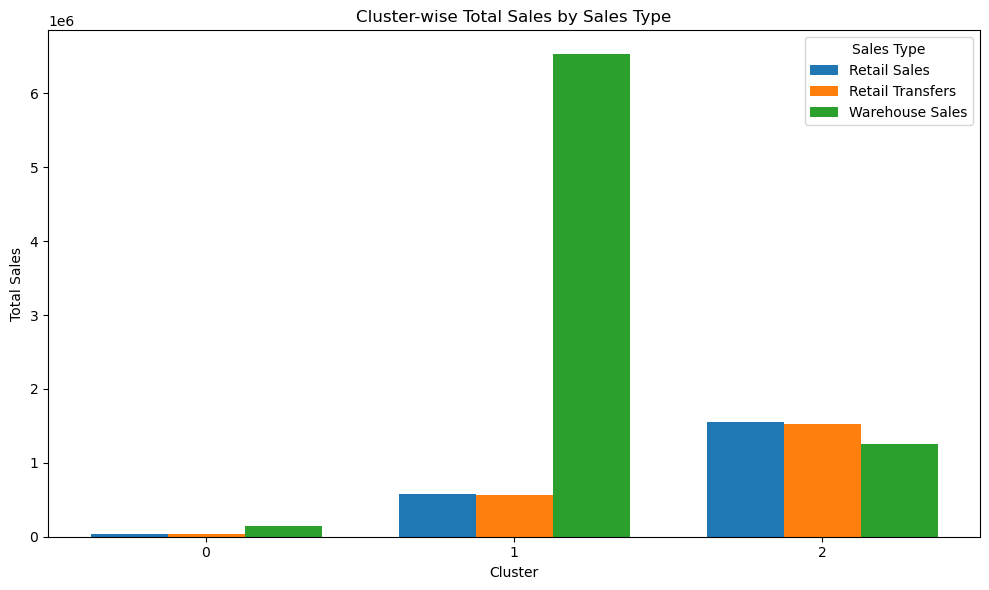

In [107]:
cluster_sales = feature_df.groupby('CLUSTER')[[
    'RETAIL_SALES_SUM', 
    'RETAIL_TRANSFERS_SUM', 
    'WAREHOUSE_SALES_SUM'
]].sum().reset_index()

# Plotting
cluster_labels = cluster_sales['CLUSTER'].astype(str)
x = np.arange(len(cluster_labels))  # the label locations
bar_width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, cluster_sales['RETAIL_SALES_SUM'], width=bar_width, label='Retail Sales')
plt.bar(x, cluster_sales['RETAIL_TRANSFERS_SUM'], width=bar_width, label='Retail Transfers')
plt.bar(x + bar_width, cluster_sales['WAREHOUSE_SALES_SUM'], width=bar_width, label='Warehouse Sales')

# Chart formatting
plt.xlabel('Cluster')
plt.ylabel('Total Sales')
plt.title('Cluster-wise Total Sales by Sales Type')
plt.xticks(x, cluster_labels)
plt.legend(title='Sales Type')
plt.tight_layout()
plt.show()


- **Cluster 1** dominates in total sales, with an extremely high contribution from **Warehouse Sales**, highlighting it as a bulk-distribution product (BEER).
- **Cluster 2** shows a balanced distribution across all three sales types, indicating a well-rounded product category (LIQUOR) with both retail and warehouse significance.
- **Cluster 0** contributes minimally across all sales types, with relatively higher dependence on **Warehouse Sales** than Retail, aligning with its label as DUNNA.
- The clear sales volume disparity across clusters validates the effectiveness of clustering in differentiating product roles in the supply cain.
